In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
df = pd.read_csv("insurance.csv")

In [ ]:
# Identify categorical and numerical features
categorical_features = ['sex', 'smoker', 'region']
numerical_features = ['age', 'bmi', 'children', 'charges']

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features
df_scaled = df_encoded.copy()
df_scaled[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

display(df_scaled.head())

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,0.298584,False,True,False,False,True
1,-1.509965,0.509621,-0.078767,-0.953689,True,False,False,True,False
2,-0.797954,0.383307,1.580926,-0.728675,True,False,False,True,False
3,-0.441948,-1.305531,-0.908614,0.719843,True,False,True,False,False
4,-0.513149,-0.292556,-0.908614,-0.776802,True,False,True,False,False


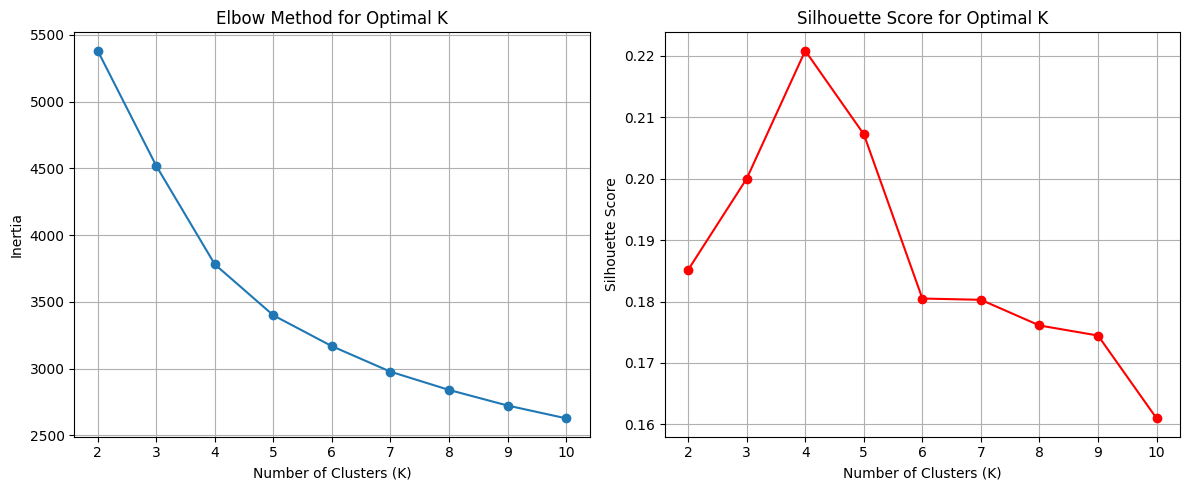

In [ ]:
# Elbow Method to find optimal K
max_k = 10
inertia = []
silhouette_scores = []

for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

    # Calculate Silhouette Score
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(df_scaled, labels))

# Plotting the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, max_k + 1), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

# Plotting the Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', color='red')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Apply K-Means with the chosen number of clusters (e.g., k=3)
optimal_k = 3 # Adjust based on Elbow and Silhouette plots
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)

display(df.head())

,age,sex,bmi,children,smoker,region,charges,cluster
0,19,female,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [ ]:
# Get the mean of each feature for each cluster
cluster_means = df.groupby('cluster').mean(numeric_only=True)
print("Cluster Means:")
display(cluster_means)

# For categorical features, we can look at counts or modes
for feature in categorical_features:
    print(f"\nCluster counts for '{feature}':")
    display(df.groupby('cluster')[feature].value_counts().unstack(fill_value=0))

Cluster Means:


,age,bmi,children,charges
cluster,,,,
0,27.278798,28.876686,1.028381,6416.293252
1,51.425129,31.245904,1.149742,12824.270335
2,39.500000,35.295063,1.145570,40895.976382



Cluster counts for 'sex':


sex,female,male
cluster,,
0,302,297
1,303,278
2,57,101



Cluster counts for 'smoker':


smoker,no,yes
cluster,,
0,533,66
1,522,59
2,9,149



Cluster counts for 'region':


region,northeast,northwest,southeast,southwest
cluster,,,,
0,147,160,153,139
1,144,137,150,150
2,33,28,61,36


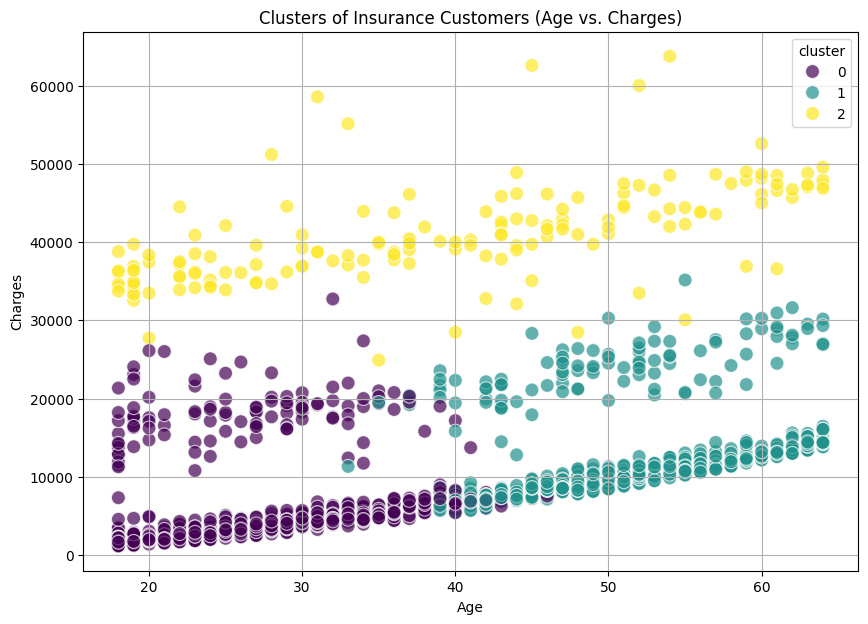

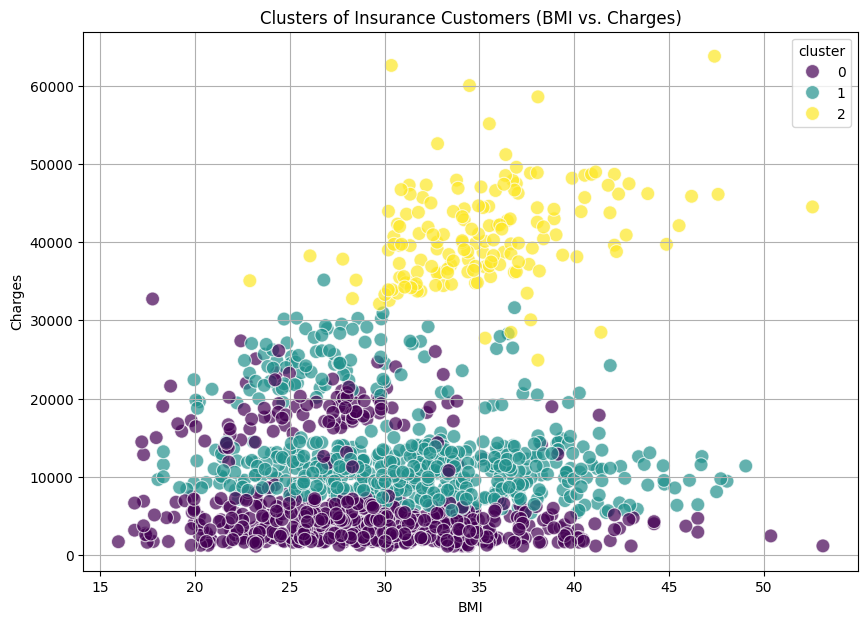

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='age', y='charges', hue='cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Clusters of Insurance Customers (Age vs. Charges)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='bmi', y='charges', hue='cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Clusters of Insurance Customers (BMI vs. Charges)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.grid(True)
plt.show()